In [ ]:
%cd /content
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
!pip install -r requirements.txt

# Lucas-Kanade

In [19]:
import torch
import cv2
from PIL import Image
from google.colab.patches import cv2_imshow
from google.colab import userdata
import matplotlib.pyplot as plt
import os

In [7]:
from google.colab import userdata
import os
#Colab Secrets에서 KAGGLE_USERNAME과 KAGGLE_KEY를 가져와 환경 변수로 설정합니다.
try:
    os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
    os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
except:
    print("User info has not been set")

    # Kaggle 데이터셋 다운로드
print("User info connected successfully!!!")
print("Kaggle credentials loaded successfully. Downloading dataset...")
#!kaggle datasets download -d balraj98/berkeley-segmentation-dataset-500-bsds500
!kaggle datasets download -d yusufberksardoan/traffic-detection-project
    # 다운로드한 파일 압축 해제
#!unzip -q berkeley-segmentation-dataset-500-bsds500.zip -d ./bsds500
!unzip -q traffic-detection-project.zip -d ./traffic_detection_project

print("Dataset Download and Unzip Complete")

User info connected successfully!!!
Kaggle credentials loaded successfully. Downloading dataset...
Dataset URL: https://www.kaggle.com/datasets/yusufberksardoan/traffic-detection-project
License(s): CC-BY-NC-SA-4.0
traffic-detection-project.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset Download and Unzip Complete


In [13]:
head_path = '/content/traffic_detection_project'

test_img_path = os.path.join(head_path, os.path.join("test", "images"))
test_label_path = os.path.join(head_path, os.path.join("test", "labels"))

train_img_path = os.path.join(head_path, os.path.join("train", "images"))
train_label_path = os.path.join(head_path, os.path.join("train", "labels"))

val_img_path = os.path.join(head_path, os.path.join("val", "images"))
val_label_path = os.path.join(head_path, os.path.join("val", "labels"))

/content/traffic_detection_project/test/images/aguanambi-1000_png_jpg.rf.7179a0df58ad6448028bc5bc21dca41e.jpg
/content/traffic_detection_project/test/images/aguanambi-1095_png_jpg.rf.4d9f0370f1c09fb2a1d1666b155911e3.jpg
/content/traffic_detection_project/test/images/aguanambi-1100_png_jpg.rf.8b7574e1c4f3fd7b654c2a693404fd2d.jpg
/content/traffic_detection_project/test/images/aguanambi-1240_png_jpg.rf.7e110b54d205ef0537ddc5dec81a79c2.jpg
/content/traffic_detection_project/test/images/aguanambi-1540_png_jpg.rf.b8ea6dd9130d82a3b6163bc3aaa823d3.jpg
/content/traffic_detection_project/test/images/aguanambi-1680_png_jpg.rf.fede1a51e422cc8fd628a4846615f65f.jpg


 /content/traffic_detection_project/test/images/aguanambi-1100_png_jpg.rf.8b7574e1c4f3fd7b654c2a693404fd2d.jpg


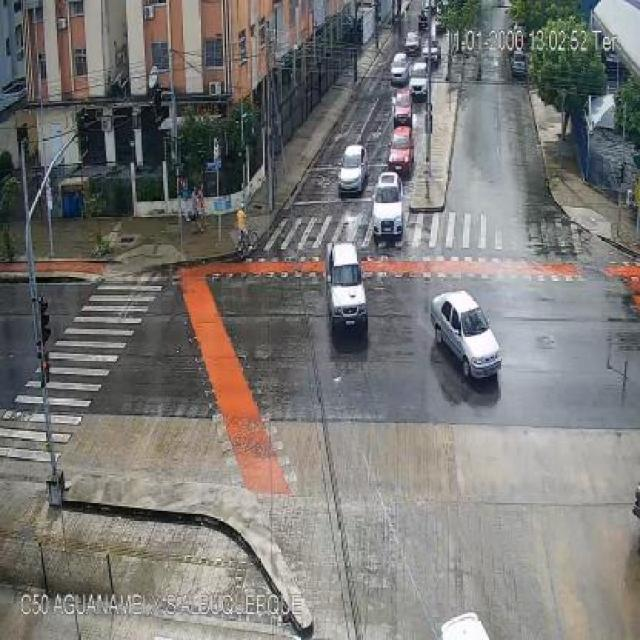

-1

In [67]:
sorted_train = sorted(os.listdir(test_img_path))
check_img_path = os.path.join(test_img_path, sorted_train[2])

for i in range(0, 6):
    print(os.path.join(test_img_path, sorted_train[i]))
check_img = cv2.imread(check_img_path)
check_img.shape
print("\n\n",check_img_path)

cv2_imshow(check_img)
cv2.waitKey(0)
cv2.destroyAllWindows()
cv2.waitKey(1)
cv2.waitKey(1)
cv2.waitKey(1)
cv2.waitKey(1)

# 0, 1, 2
# 3, 4, 5, 6
# 7, 8, 9, 10

In [68]:
check_img.shape

(640, 640, 3)

In [72]:
frame_files = []
for i in range(3):
    frame_files.append(os.path.join(test_img_path, sorted_train[i]))

for i in range(7,11):
    frame_files.append(os.path.join(test_img_path, sorted_train[i]))


first_frame = cv2.imread(os.path.join(test_img_path, sorted_train[0]))
height, width, _ = first_frame.shape

fourcc = cv2.VideoWriter_fourcc(*'mp4v')

out = cv2.VideoWriter(
    "output.mp4",
    fourcc,
    30,
    (width, height)
)

for file in frame_files:
    frame_path = os.path.join(test_img_path, file)
    frame = cv2.imread(frame_path)
    out.write(frame)

out.release()
print("Video saved as output.mp4")

Video saved as output.mp4


# Tennis

In [93]:
import numpy as np

In [85]:
!unzip -q tennis.zip -d ./tennis
print("Dataset Download and Unzip Complete")

replace ./tennis/__MACOSX/._tennis? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Dataset Download and Unzip Complete


In [87]:
tennis_path = '/content/tennis/tennis'

sorted_tennis = sorted(os.listdir(tennis_path))

In [92]:
first_frame = cv2.imread(os.path.join(tennis_path, sorted_tennis[0]))
height, width, _ = first_frame.shape

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(
    "tennis.mp4",
    fourcc,
    30,
    (width, height)
)

for file in sorted_tennis:
    frame_path = os.path.join(tennis_path, file)
    frame = cv2.imread(frame_path)
    out.write(frame)

out.release()
print("Tennis Video saved as tennis.mp4")

Tennis Video saved as tennis.mp4


In [99]:
cap = cv2.VideoCapture("/content/tennis.mp4")

feature_params = dict(maxCorners=50, qualityLevel=0.3, minDistance=7, blockSize=7) # 오타 수정: minDistnace -> minDistance
lk_params = dict(winSize=(15, 15), maxLevel=2, criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))

color = np.random.randint(0, 255, (100, 3))

first_frame = cv2.imread(os.path.join(tennis_path, sorted_tennis[0]))
old_gray = cv2.cvtColor(first_frame, cv2.COLOR_BGR2GRAY)
p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)

mask = np.zeros_like(first_frame)

fourcc_new = cv2.VideoWriter_fourcc(*"mp4v")
out_new = cv2.VideoWriter("tennis_with_optical_flow.mp4", fourcc_new, 30, (width, height))

mask = np.zeros_like(frame)
for file in sorted_tennis:
    frame_path = os.path.join(tennis_path, file)
    frame = cv2.imread(frame_path)
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Fix: Corrected typo in cv2.calcOpticalFlowPyrLK
    p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None, **lk_params)

    if p1 is not None and st is not None:
        good_new = p1[st == 1]
        good_old = p0[st == 1]

        for i, (new, old) in enumerate(zip(good_new, good_old)):
            # Fix: Corrected attribute access from .reval() to .ravel().astype(int)
            a, b = new.ravel().astype(int)
            c, d = old.ravel().astype(int)

            mask = cv2.line(mask, (a, b), (c, d), color[i].tolist(), 2)
            frame = cv2.circle(frame, (a, b), 5, color[i].tolist(), -1)

        img = cv2.add(frame, mask)

        old_gray = frame_gray.copy()
        p0 = good_new.reshape(-1, 1, 2)
        out_new.write(img)
    else:
        # Handle case where no points are found or tracked
        old_gray = frame_gray.copy()
        p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params) # Re-detect features
        if p0 is None or len(p0) == 0:
            continue
        img = frame
        out_new.write(img)


out_new.release()
print("Tennis with OpticalFlow saved as tennis_with_optical_flow.mp4")

Tennis with OpticalFlow saved as tennis_with_optical_flow.mp4


In [ ]:

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None, **lk_params)

    good_new = p1[st==1]
    good_old = p0[st==1]

    for i, (new, old) in enumerate(zip(good_new, good_old)):
        a, b = new.ravel()
        c, d = old.ravel()
        a, b, c, d = int(a), int(b), int(c), int(d)
        mask = cv2.line(mask, (a, b), (c, d), color[i].tolist(), 2)
        frame = cv2.circle(frame, (a, b), 5, color[i].tolist(), -1)
    img = cv2.add(frame, mask)

    cv2_imshow(img)
    k = cv2.waitKey(30)
    if k == 27:
        break

    old_gray = frame_gray.copy()
    p0 = good_new.reshape(-1, 1, 2)


cv2.destroyAllWindows
cap.release()